# Groep G09
**Naam:** Evy Coulier  
**Studentennummer:** 202408981

### Overzicht van de analyses
* **Reeks 1:** Analyse 3
* **Reeks 2:** Analyse 1
* **Reeks 3:** Analyse 2

In [65]:
# Importeren van benodigde libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

# Database engine aanmaken
engine = get_engine()
print("Database connectie succesvol opgezet")

Database connectie succesvol opgezet


## Reeks 1 Analyse 3
**1.** Schrijf een functie die voor een opgegeven jaar of voor een opgegeven jaar en maand het gemiddeld aantal fietsuitleningen per uur berekent in een opgegeven Blue-bike punt. Maak een onderscheid tussen weekdag en weekend. Maak een plot.

De functie **fietsUitleningenPerUur** berekent het gemiddeld aantal fietsuitleningen per uur voor een Blue-bike station.

**Wat er in de functie gebeurt**:
1. Formatteer de maand parameter naar 2 cijfers (bijv. 3 -> '03')
2. Voer de sql query uit met een CTE om de fietsuitleningen voor de meegegeven maand en jaar te berekenen
   - LAG functie vergelijkt huidige BikesInUse met vorige waarde
   - Als BikesInUse stijgt zijn er fietsen uitgeleend
3. Groepeer de data eerst per dag en uur om dagelijkse totalen te krijgen
4. Bereken daarna het gemiddelde over alle dagen
    
**Parameters**:
   - id: BlueBikeStationKey (identificatie van het Blue-bike punt)
   - jaar: het jaar waarvoor de analyse wordt uitgevoerd
   - maand: (optioneel) specifieke maand om te analyseren
    
**Returns**:
   - DataFrame met kolommen: Uur, IsWeekend, AantalUitleningen (gemiddeld)

In [66]:
def fietsUitleningenPerUur(id, jaar, maand=''):
    if maand != '':
        maand = f"{int(maand):02d}"
    try:
        query = f"""
        WITH BikesUitgeleend AS (
            SELECT 
                BlueBikeStationKey,
                DateKey,
                TimeKey,
                BikesInUse,
                LAG(BikesInUse) OVER (
                    PARTITION BY BlueBikeStationKey, DateKey 
                    ORDER BY TimeKey
                ) AS PrevBikesInUse
            FROM FactBlueBike
            WHERE BlueBikeStationKey = {id}
            AND DateKey like '{jaar}{maand}%'
        )
        SELECT 
            Hour AS Uur,
            IsWeekend,
            dd.DateKey,
            CAST(
                CASE 
                    WHEN PrevBikesInUse < BikesInUse 
                    THEN BikesInUse - PrevBikesInUse
                    ELSE 0
                END 
            AS FLOAT) AS AantalUitleningen
        FROM BikesUitgeleend bu 
        JOIN DimTime dt ON bu.TimeKey = dt.TimeKey
        JOIN DimDate dd ON bu.DateKey = dd.DateKey
        WHERE PrevBikesInUse IS NOT NULL
        ORDER BY IsWeekend, Hour
        """
    
        df = getData(engine, query)

        if df is None or df.empty:
            print(f"Geen data gevonden voor id = {id} in jaar = {jaar} {"maand = " + maand if maand != '' else maand}")
            return None

        df = df.groupby(
            ["DateKey", "Uur", "IsWeekend"],
            as_index=False
        )["AantalUitleningen"].sum()

        df = df.groupby(
            ["Uur", "IsWeekend"],
            as_index=False
        )["AantalUitleningen"].mean()
                
        return df
    
    except Exception as e:
        print(f"Fout bij ophalen of verwerken van data: {e}")
        return None

**Visualisatie** van de data die je krijgt na het uitvoeren van de functie fietsUitleningenPerUur. 

Als voorbeeld wordt BlueBike station met id 48 voor de maand maart in het jaar 2026 geanalyseerd.

Eerst wordt de data opgesplitst in weekdag data en weekend data
- IsWeekend = False betekent weekdag, True betekent weekend

In [67]:
df = fietsUitleningenPerUur(id=48, jaar=2026, maand=3)
weekdag_data = df[~df['IsWeekend']]
weekend_data = df[df['IsWeekend']]
print(df.head())
print(weekdag_data.head())
print(weekend_data.head())


   Uur  IsWeekend  AantalUitleningen
0    0      False              0.000
1    0       True              0.375
2    1      False              0.000
3    1       True              0.125
4    2      False              0.000
   Uur  IsWeekend  AantalUitleningen
0    0      False                0.0
2    1      False                0.0
4    2      False                0.0
6    3      False                0.0
8    4      False                0.0
   Uur  IsWeekend  AantalUitleningen
1    0       True              0.375
3    1       True              0.125
5    2       True              0.000
7    3       True              0.000
9    4       True              0.000


Plot een lijn grafiek, want visueel zie je dan het gemakkelijkst de verschillen tussen weekend en weekdag

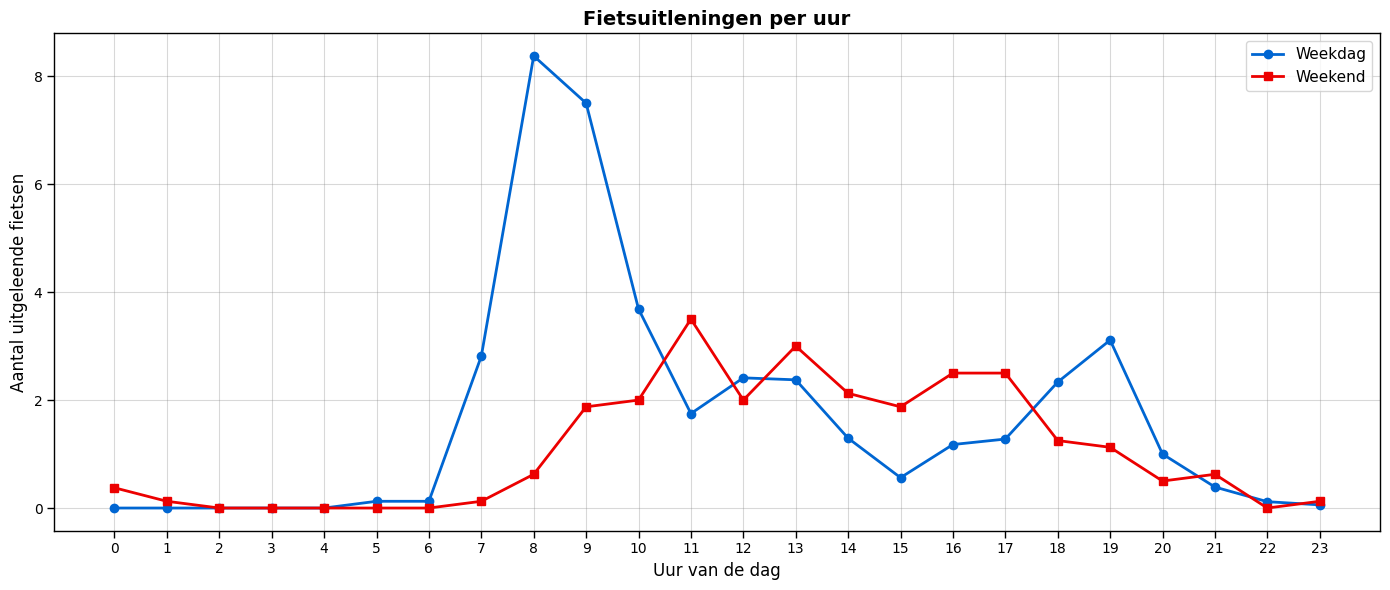

In [68]:

plt.figure(figsize=(14, 6))

plt.plot(weekdag_data['Uur'], weekdag_data['AantalUitleningen'], 
        marker='o', linewidth=2, label='Weekdag', color="#0066D2")
plt.plot(weekend_data['Uur'], weekend_data['AantalUitleningen'], 
        marker='s', linewidth=2, label='Weekend', color="#EC0000")

plt.xlabel('Uur van de dag', fontsize=12)
plt.ylabel('Aantal uitgeleende fietsen', fontsize=12)
plt.title(f'Fietsuitleningen per uur', 
        fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(range(0, 24))

ax = plt.gca()

ax.set_facecolor("white")
ax.grid(True, color="gray", alpha=0.3)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=5,
    width=1,
    colors='black'
)

plt.tight_layout()
plt.show()

**Conclusie**: Tijdens weekdagen zijn er duidelijke pieken tijdens spitsuren (ochtend en avond). Vooral in de ochtend worden veel fietsen uitgeleend op een weekdag. In het weekend is de verdeling gelijkmatiger over de dag. Zowel in het weekend als op weekdagen worden er 's nachts weinig fietsen uitgeleend.

**2.** Schrijf een functie die voor een gegeven jaar of voor een gegeven jaar en maand het totaal aantal fietsuitleningen per dag berekent in een opgegeven Blue-bike punt. Maak een onderscheid tussen e-bikes en klassieke blue-bikes. Maak een plot.

De functie **UitleningenPerDag** berekent het totaal aantal fietsuitleningen per dag, voor een opgegeven jaar (en maand) voor de gewone Blue Bikes en de elektrische Blue Bike.
    
**Wat er in de functie gebeurt**:
1. Formatteer de maand parameter
2. Voer de sql query uit met een CTE om de uitleningen van de fietsen berekenen
   - LAG functie vergelijkt huidige aantal fietsen met vorige waarde
   - Als aantal fietsen available daalt zijn er fietsen uitgeleend
3. Bereken per dag totaal aantal uitleningen voor beide types
4. Format datum voor betere leesbaarheid in plot
    
**Parameters**:
   - id: BlueBikeStationKey
   - jaar: jaar voor analyse
   - maand: (optioneel) specifieke maand
    
**Returns**:
   - DataFrame met DayOfMonth, DateKey, EBikeUitleningen, BlueBikeUitleningen, Datum

In [69]:
def UitleningenPerDag(id, jaar, maand=''):
    if maand != '':
        maand = f"{int(maand):02d}"
    try:        
        query = f"""
        WITH Uitleningen AS (
            SELECT 
                DateKey,
                TimeKey,
                EBikesAvailable,
                BlueBikesAvailable,
                LAG(EBikesAvailable) OVER (
                    PARTITION BY BlueBikeStationKey, DateKey 
                    ORDER BY TimeKey
                ) AS PrevEBikes,
                LAG(BlueBikesAvailable) OVER (
                    PARTITION BY BlueBikeStationKey, DateKey 
                    ORDER BY TimeKey
                ) AS PrevBlueBikes
            FROM FactBlueBike 
            WHERE BlueBikeStationKey = {id}
                AND DateKey like '{jaar}{maand}%'
        )

        SELECT 
            dd.DayOfMonth,
            u.DateKey,
            CASE 
                WHEN PrevEBikes > EBikesAvailable 
                THEN PrevEBikes - EBikesAvailable 
                ELSE 0 
            END AS EBikeUitleningen,
            CASE 
                WHEN PrevBlueBikes > BlueBikesAvailable 
                THEN PrevBlueBikes - BlueBikesAvailable 
                ELSE 0 
            END AS BlueBikeUitleningen

        FROM Uitleningen u
        join DimDate dd on dd.DateKey = u.DateKey
        WHERE PrevEBikes IS NOT NULL OR PrevBlueBikes IS NOT NULL
        ORDER BY u.DateKey, TimeKey;
        """
        
        # Data ophalen uit database
        df = getData(engine, query)
        df = (
            df.groupby(["DayOfMonth", "DateKey"], as_index=False)
            .agg({
                "EBikeUitleningen": "sum",
                "BlueBikeUitleningen": "sum",
            })
            .sort_values("DateKey")
        )
        df["Datum"] = pd.to_datetime(df["DateKey"], format="%Y%m%d").dt.strftime("%d-%m")
        return df
    except Exception as e:
        print(f"Fout bij ophalen of verwerken van data: {e}")
        return None

**Visualisatie** van de data die je krijgt na het uitvoeren van de functie UitleningenPerDag. 

Als voorbeeld wordt BlueBike station met id 133 voor de maand maart in het jaar 2026 geanalyseerd.

In [70]:
df = UitleningenPerDag(id=133, jaar=2026, maand=3)
df.head()

,DayOfMonth,DateKey,EBikeUitleningen,BlueBikeUitleningen,Datum
0,3,20260303,0,4,03-03
1,4,20260304,0,3,04-03
2,5,20260305,4,80,05-03
3,6,20260306,2,64,06-03
4,7,20260307,0,31,07-03


Plot een bar grafiek om de verschillen te zijn tussen de e-bikes en de gewone bikes.

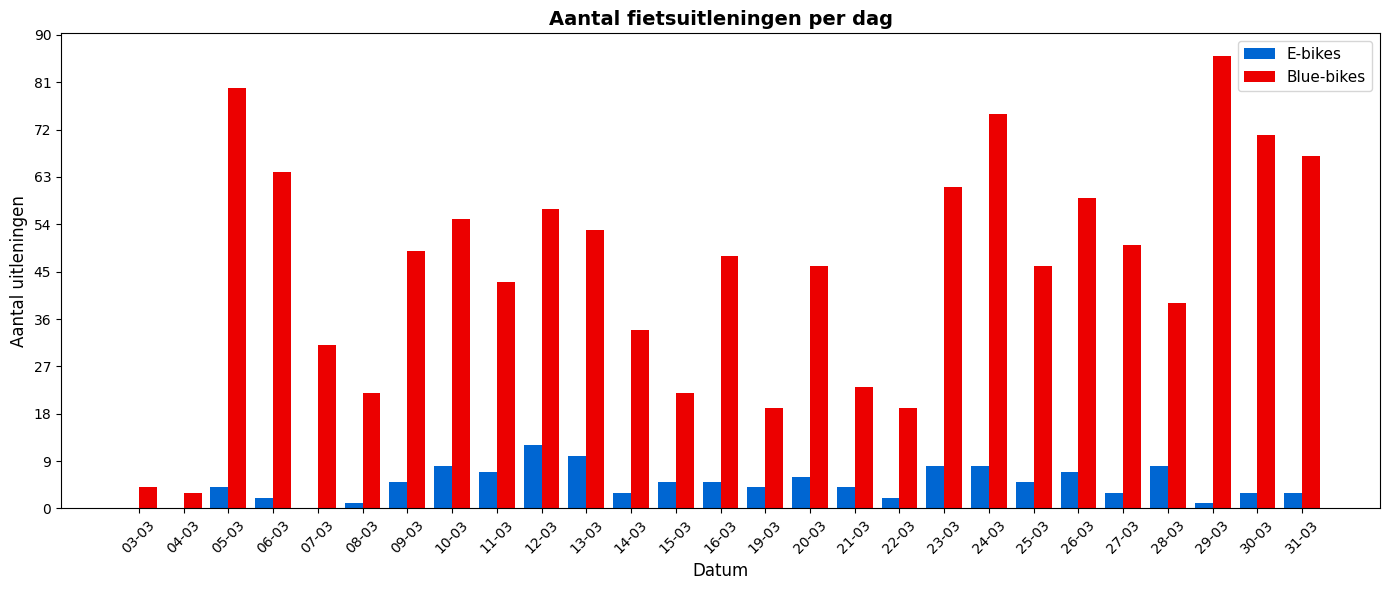

In [71]:
x = np.arange(len(df))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(x - width/2, df["EBikeUitleningen"], width, label="E-bikes", color="#0066D2")
plt.bar(x + width/2, df["BlueBikeUitleningen"], width, label="Blue-bikes", color="#EC0000")

plt.xticks(x, df["Datum"], rotation=45)
plt.xlabel("Datum", fontsize=12)
plt.ylabel("Aantal uitleningen", fontsize=12)
plt.title("Aantal fietsuitleningen per dag", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)

max_val = int(df[["EBikeUitleningen", "BlueBikeUitleningen"]].values.max())
step = max(1, round(max_val / 10))
plt.yticks(range(0, max_val + step, step))

plt.tight_layout()
plt.show()

**Conclusie**: Het aantal uitleningen van de e-bikes en Blue Bikes volgen een gelijkaardige trend voor iedere dag. Er zijn wel duidelijke fluctuaties per dag (mogelijk weekend vs weekdag effect).

## Reeks 2 Analyse 1
Maak een analyse over de invloed van het seizoen op het aantal fietsers die geteld worden aan de fietstelpalen. Zijn de verschillen tussen de seizoen significant? Maak een plot.

**SQL-query**: Data ophalen met seizoen informatie
We definiëren seizoenen op basis van maanden:
  - Winter: december, januari, februari
  - Lente: maart, april, mei
  - Zomer: juni, juli, augustus
  - Herfst: september, oktober, november

In [72]:
# SQL query om tellingen per dag op te halen met seizoen informatie
query = """
SELECT 
    CASE 
        WHEN d.Month IN (12, 1, 2) THEN 'Winter'
        WHEN d.Month IN (3, 4, 5) THEN 'Lente'
        WHEN d.Month IN (6, 7, 8) THEN 'Zomer'
        WHEN d.Month IN (9, 10, 11) THEN 'Herfst'
    END AS Seizoen,
    
    d.Year,
    
    AVG(f.TotalCounts) AS AvgFietsers

FROM FactCountings f
JOIN DimDate d ON f.DateKey = d.DateKey

GROUP BY 
    d.Year,
    CASE 
        WHEN d.Month IN (12, 1, 2) THEN 'Winter'
        WHEN d.Month IN (3, 4, 5) THEN 'Lente'
        WHEN d.Month IN (6, 7, 8) THEN 'Zomer'
        WHEN d.Month IN (9, 10, 11) THEN 'Herfst'
    END

ORDER BY d.Year, Seizoen;
"""
df = getData(engine, query)
df.head()

,Seizoen,Year,AvgFietsers
0,Herfst,2020,834
1,Lente,2020,952
2,Winter,2020,536
3,Zomer,2020,972
4,Herfst,2021,841


**Visualisatie 1**: Vergelijking per jaar het gemiddeld aantal fietsers in een seizoen. Met een bar grafiek per jaar zie je het verschil in aantal fietsers per jaar en ook nog eens het verschil tussen de seizoenen in 1 jaar.

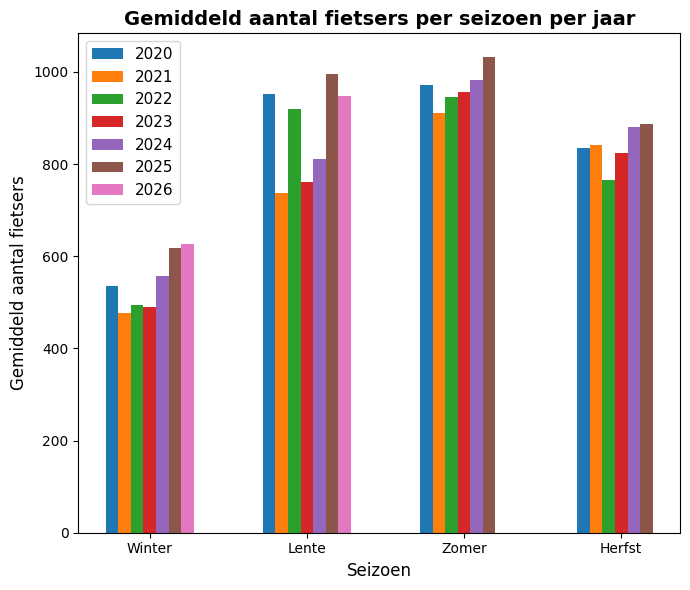

In [73]:
order = ['Winter', 'Lente', 'Zomer', 'Herfst']
jaren = sorted(df['Year'].unique())

x = np.arange(len(order))
width = 0.08

plt.figure(figsize=(7, 6))

for i, jaar in enumerate(jaren):
    df_jaar = df[df['Year'] == jaar]
    df_jaar = df_jaar.set_index('Seizoen').reindex(order)
    plt.bar(x + i * width, df_jaar['AvgFietsers'], width, label=jaar)

plt.xticks(x + width * (len(jaren)-1)/2, order)

plt.title("Gemiddeld aantal fietsers per seizoen per jaar", fontsize=14, fontweight="bold")
plt.xlabel("Seizoen", fontsize=12)
plt.ylabel("Gemiddeld aantal fietsers", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

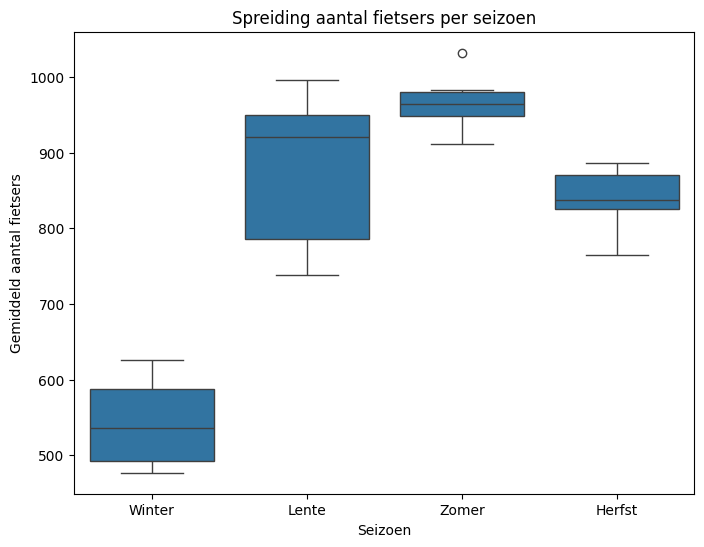

In [74]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='Seizoen', y='AvgFietsers', order=order)

plt.title("Spreiding aantal fietsers per seizoen")
plt.xlabel("Seizoen")
plt.ylabel("Gemiddeld aantal fietsers")

plt.show()

In [75]:
def mean_median_quantile(df):
    mean = np.mean(df)
    median = np.median(df)
    lowerQ = np.quantile(df, 0.25)                 # np.percentile(l, 25)
    UpperQ = np.quantile(df, 0.75)                 # np.percentile(l, 75)
    print(f"\tMean = {mean}\n\tMedian = {median}\n\tLowerQ = {lowerQ}\n\tUpperQ = {UpperQ}")

In [76]:
winter = df[df['Seizoen'] == 'Winter']['AvgFietsers']
lente = df[df['Seizoen'] == 'Lente']['AvgFietsers']
zomer = df[df['Seizoen'] == 'Zomer']['AvgFietsers']
herfst = df[df['Seizoen'] == 'Herfst']['AvgFietsers']
print("Winter:")
mean_median_quantile(winter)
print("Lente:")
mean_median_quantile(lente)
print("Zomer:")
mean_median_quantile(zomer)
print("Herfst:")
mean_median_quantile(herfst)

Winter:
	Mean = 542.4285714285714
	Median = 536.0
	LowerQ = 492.0
	UpperQ = 587.0
Lente:
	Mean = 875.0
	Median = 920.0
	LowerQ = 786.0
	UpperQ = 949.5
Zomer:
	Mean = 966.6666666666666
	Median = 964.5
	LowerQ = 948.0
	UpperQ = 980.25
Herfst:
	Mean = 838.3333333333334
	Median = 837.5
	LowerQ = 825.75
	UpperQ = 871.0


In [77]:
print("Winter vs Lente:", stats.ttest_ind(winter, lente))
print("Winter vs Zomer:", stats.ttest_ind(winter, zomer))
print("Winter vs Herfst:", stats.ttest_ind(winter, herfst))

print("Lente vs Zomer:", stats.ttest_ind(lente, zomer))
print("Lente vs Herfst:", stats.ttest_ind(lente, herfst))

print("Zomer vs Herfst:", stats.ttest_ind(zomer, herfst))

Winter vs Lente: TtestResult(statistic=np.float64(-7.347932346752968), pvalue=np.float64(8.878784613578295e-06), df=np.float64(12.0))
Winter vs Zomer: TtestResult(statistic=np.float64(-14.476356097661721), pvalue=np.float64(1.655642675724297e-08), df=np.float64(11.0))
Winter vs Herfst: TtestResult(statistic=np.float64(-9.856955889275529), pvalue=np.float64(8.536182415673918e-07), df=np.float64(11.0))
Lente vs Zomer: TtestResult(statistic=np.float64(-2.037009457596998), pvalue=np.float64(0.06644509000274593), df=np.float64(11.0))
Lente vs Herfst: TtestResult(statistic=np.float64(0.8064099363693878), pvalue=np.float64(0.43709408044296316), df=np.float64(11.0))
Zomer vs Herfst: TtestResult(statistic=np.float64(5.245504231851393), pvalue=np.float64(0.00037580988413698054), df=np.float64(10.0))


**De onafhankelijke t-tests tonen dat:**

- Winter vs Lente: significant verschil (p < 0.001)
- Winter vs Zomer: significant verschil (p < 0.001)
- Winter vs Herfst: significant verschil (p < 0.001)

→ De winter verschilt dus duidelijk van alle andere seizoenen.

- Zomer vs Herfst: ook significant verschil (p < 0.001)
- Lente vs Zomer: geen significant verschil (p ≈ 0.066)
- Lente vs Herfst: geen significant verschil (p ≈ 0.437)

**Visualisatie 2**: Vergelijking het gemiddeld aantal fietsers per seizoen. Opnieuw met een bar grafiek maar nu per seizoen zie je het verschil in aantal fietsers per seizoen.

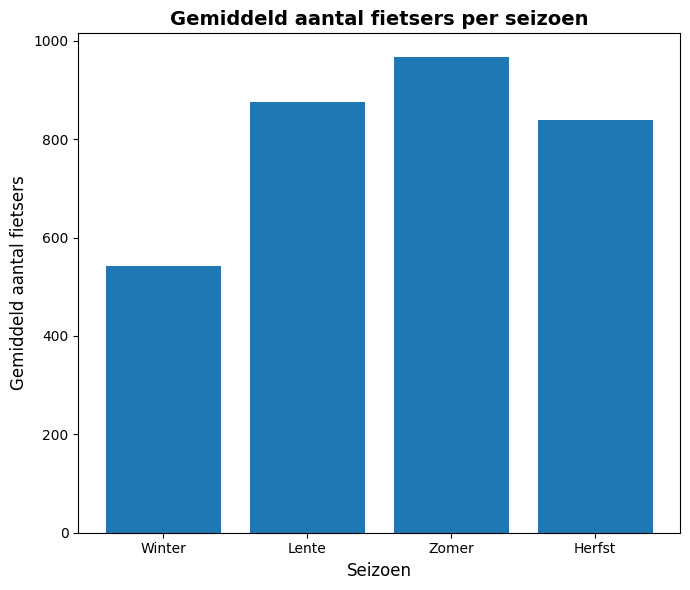

In [78]:
plt.figure(figsize=(7, 6))

df_totaal = df.groupby('Seizoen')['AvgFietsers'].mean().reset_index()
df_totaal = df_totaal.set_index('Seizoen').reindex(order)
plt.bar(x, df_totaal['AvgFietsers'])

plt.xticks(x, order)

plt.title("Gemiddeld aantal fietsers per seizoen", fontsize=14, fontweight="bold")
plt.xlabel("Seizoen", fontsize=12)
plt.ylabel("Gemiddeld aantal fietsers", fontsize=12)

plt.tight_layout()
plt.show()

In [79]:
df_totaal

,AvgFietsers
Seizoen,
Winter,542.428571
Lente,875.000000
Zomer,966.666667
Herfst,838.333333


**Conclusie**: De beschrijvende statistieken tonen duidelijke verschillen tussen de seizoenen.
De winter heeft het laagste gemiddelde aantal fietsers (≈ 542), terwijl de zomer het hoogste gemiddelde bereikt (≈ 967). De lente en herfst liggen hier tussenin.
We kunnen ook concluderen dat het seizoen een significante invloed heeft op het aantal fietsers.
Vooral de winter wijkt sterk af van de andere seizoenen, met aanzienlijk lagere aantallen.
Daarnaast is er ook een significant verschil tussen zomer en herfst.
De verschillen tussen lente, zomer en herfst onderling zijn echter minder uitgesproken.

## Reeks 3 Analyse 2
Vergelijk de geschatte CO2 uitstoot veroorzaakt door de studenten van het vak DEP1 met de geschatte CO2 uitstoot veroorzaakt door het personeel - per persoon.

**SQL-query**: CTE berekent totale CO2 per student (afstand × CO2 per km) en daarna wordt het gemiddelde genomen over alle studenten.

In [80]:
query_students = """
SELECT
    ds.StudentKey,
    SUM(fs.DistanceKM * dtr.CO2PerKM) AS TotalCO2
FROM FactStudentMobility fs
JOIN DimStudent ds ON fs.StudentKey = ds.StudentKey
JOIN DimTransportType dtr ON fs.TransportKey = dtr.TransportKey
GROUP BY ds.StudentKey;
"""

students = getData(engine, query_students)
students.dropna(subset='TotalCO2', inplace=True)
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentKey  62 non-null     int64  
 1   TotalCO2    62 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


**SQL-query**: CTE berekent totale CO2 per werknemer en daarna wordt het gemiddelde genomen over alle werknemers.

In [63]:
query_workers = """
SELECT
    w.WorkerID,
    SUM(fwm.TotalEmission) AS TotalCO2
FROM FactWorkerMobility fwm
JOIN DimWorkerMobility w ON fwm.WorkerID = w.WorkerID
GROUP BY w.WorkerID;
"""

workers = getData(engine,query_workers)
workers.dropna(subset='TotalCO2', inplace=True)
workers.info()

<class 'pandas.DataFrame'>
Index: 593 entries, 0 to 663
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   WorkerID  593 non-null    int64  
 1   TotalCO2  593 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 13.9 KB


Data combineren voor vergelijking

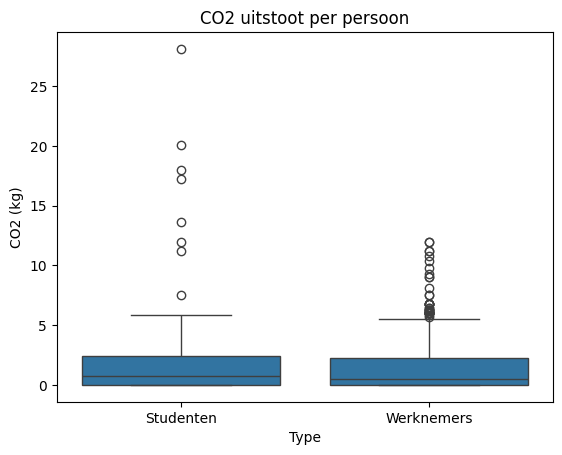

In [82]:
students['Type'] = 'Studenten'
workers['Type'] = 'Werknemers'

df = pd.concat([
    students[['TotalCO2', 'Type']],
    workers[['TotalCO2', 'Type']]
])

sns.boxplot(x='Type', y='TotalCO2', data=df)

plt.title("CO2 uitstoot per persoon")
plt.ylabel("CO2 (kg)")
plt.show()

In [83]:
print("Studenten:")
print(students['TotalCO2'].describe())
print("Werknemers:")
print(workers['TotalCO2'].describe())

Studenten:
count    62.000000
mean      2.935323
std       5.672986
min       0.000000
25%       0.000000
50%       0.720000
75%       2.427500
max      28.130000
Name: TotalCO2, dtype: float64
Werknemers:
count    593.000000
mean       1.487673
std        2.211655
min        0.000000
25%        0.000000
50%        0.500000
75%        2.250000
max       12.000000
Name: TotalCO2, dtype: float64


In [84]:
stat, p = stats.ttest_ind(
    students['TotalCO2'],
    workers['TotalCO2'],
    equal_var=False
)

print("p-value:", p)

p-value: 0.05053998683922981


In [35]:
avg_students = students['TotalCO2'].mean()
avg_workers = workers['TotalCO2'].mean()

data = pd.DataFrame({
    "Group": ["Studenten DEP1", "Personeel HOGENT"],
    "AvgCO2": [avg_students, avg_workers]
})

data

,Group,AvgCO2
0,Studenten DEP1,2.935323
1,Personeel HOGENT,1.487673


**Visualisatie 1**: Bar grafiek voor het vergelijken van het gemiddelde CO2 gebruik van de studenten en van de werknemers.

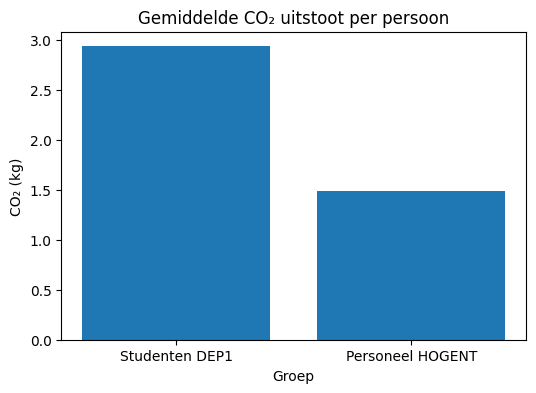

In [36]:
plt.figure(figsize=(6,4))

plt.bar(data["Group"], data["AvgCO2"])

plt.title("Gemiddelde CO₂ uitstoot per persoon")
plt.ylabel("CO₂ (kg)")
plt.xlabel("Groep")

plt.show()

**SQL-query** om verdeling van vervoersmiddelen te vergelijken.

In [39]:
query1 = """
SELECT 
    dt.VehicleType,
    COUNT(*) AS TransportCount
FROM FactStudentMobility fsm
JOIN DimTransportType dt 
    ON fsm.TransportKey = dt.TransportKey
JOIN DimStudent s
    ON fsm.StudentKey = s.StudentKey
GROUP BY dt.VehicleType
"""
query2 = """
SELECT 
    dt.VehicleType,
    COUNT(*) AS TransportCount
FROM FactWorkerMobility fwm
JOIN DimTransportType dt 
    ON fwm.TransportKey = dt.TransportKey
JOIN DimWorkerMobility w
    ON fwm.WorkerID = w.WorkerID
GROUP BY dt.VehicleType;
"""

students = getData(engine, query1)
workers = getData(engine, query2)
print(students)
print(workers)

  VehicleType  TransportCount
0        Auto              45
1         Bus              12
2       Fiets              66
3     Te voet              37
4       Trein              57
  VehicleType  TransportCount
0        Auto             201
1         Bus              15
2       Fiets             264
3       Trein             113


**Visualisatie 2**: Taart grafieken om de verdeling van types transport die gebruikt worden door de studenten en de werknemers te zien.

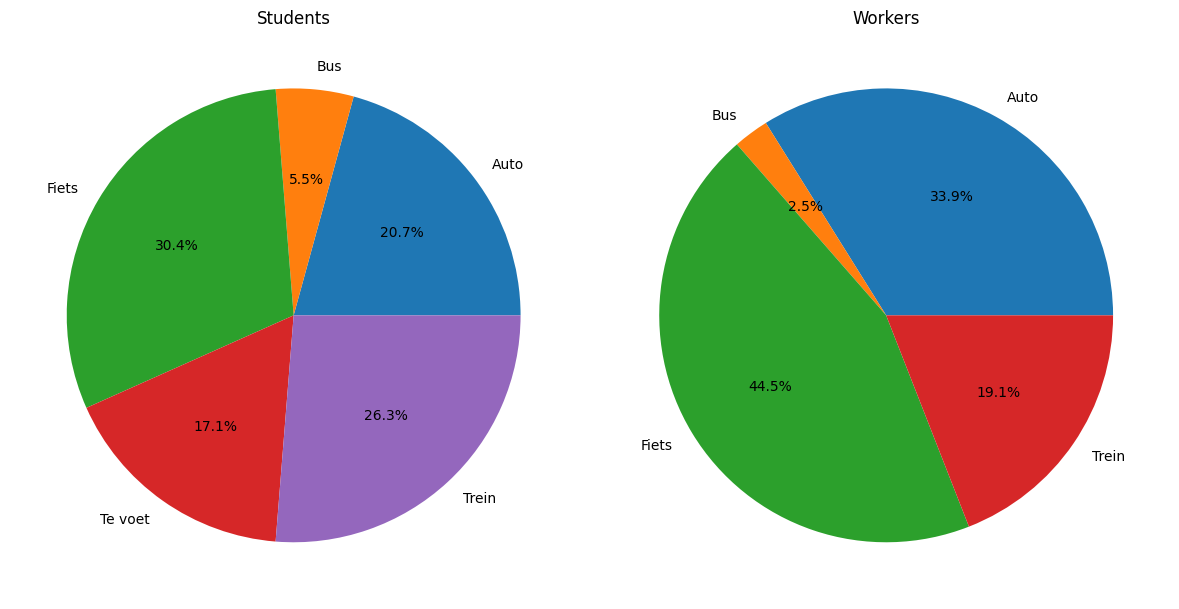

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].pie(
    students["TransportCount"],
    labels=students["VehicleType"],
    autopct="%1.1f%%"
)
axes[0].set_title("Students")

axes[1].pie(
    workers["TransportCount"],
    labels=workers["VehicleType"],
    autopct="%1.1f%%"
)
axes[1].set_title("Workers")

plt.tight_layout()
plt.show()

**Conclusie**: De studenten stoten gemiddeld meer CO₂ uit (≈ 2.94 kg) dan het personeel (≈ 1.49 kg).
Daarnaast is de spreiding bij studenten duidelijk groter (std ≈ 5.67) dan bij werknemers (std ≈ 2.21), wat wijst op grotere variatie in mobiliteitsgedrag bij studenten.
De mediaan ligt bij beide groepen relatief laag, en een groot deel van de waarden bevindt zich rond 0, wat erop wijst dat veel personen weinig of geen uitstoot genereren.

De onafhankelijke t-test geeft een p-waarde van 0.0505, wat net boven de gebruikelijke significantiedrempel van 0.05 ligt.

Hoewel er een duidelijke trend is dat studenten meer uitstoten, is het verschil net niet statistisch significant (p ≈ 0.051). Hierdoor kunnen we niet met zekerheid stellen dat het verschil niet op toeval berust.